In [ ]:
# Step 1: Load the data
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency

df = pd.read_csv('project_data.csv')

In [ ]:
# Step 2: Print column names and shape
print("Column names:", df.columns.tolist())
print("Dataframe shape:", df.shape)

Column names: ['Unnamed: 0', 'Tweet', 'Followers', 'Friends', 'Num_tweets', 'Verified', 'Listed_count', 'Location', 'Age', 'Length', 'Num_users', 'Num_author_replies', 'TOXICITY_x', 'Num_toxic_direct_replies', 'Num_toxic_nested_replies', 'Num_author_toxic_replies', 'Num_toxic_replies', 'Toxic']
Dataframe shape: (28823, 18)


**Interpretation for Step 2:**  

The dataset has 28,823 observations and 18 columns based on the shape output.

In [ ]:
# Step 3: Inspect data types
df.dtypes

,0
Unnamed: 0,int64
Tweet,int64
Followers,int64
Friends,float64
Num_tweets,int64
Verified,bool
Listed_count,int64
Location,object
Age,int64
Length,int64


**Interpretation for Step 3:**  

The dataset contains integer, floating-point, boolean, and object variables as listed:


- **Integer variables (int64):** Unnamed: 0, Tweet, Followers, Num_tweets, Listed_count, Age, Length, Num_users, Num_author_replies, Toxic
- **Floating-point variables (float64):** Friends, TOXICITY_x, Num_toxic_direct_replies, Num_toxic_nested_replies, Num_author_toxic_replies, Num_toxic_replies
- **Boolean variable (bool):** Verified
- **Object/Text variable (object):** Location


In [ ]:
# Step 4: Remove rows with missing values
initial_rows = df.shape[0]
df = df.dropna()
removed_rows = initial_rows - df.shape[0]
print("Rows removed with missing values:", removed_rows)
print("New shape:", df.shape)

Rows removed with missing values: 2
New shape: (28821, 18)


**Interpretation for Step 4:**  

2 rows contained missing values and were removed from the dataset. The cleaned dataset now has 28,821 rows.

In [ ]:
# Step 5: Remove duplicate rows
initial_rows = df.shape[0]
df = df.drop_duplicates()
removed_rows = initial_rows - df.shape[0]
print("Duplicate rows removed:", removed_rows)
print("New shape:", df.shape)

Duplicate rows removed: 3
New shape: (28818, 18)


**Interpretation for Step 5:**  

3 duplicate rows were removed from the dataset. The final cleaned dataset now has 28,818 rows.

In [ ]:
# Step 6: Transform Toxicity column to binary (with column rename)
df = df.rename(columns={'TOXICITY_x': 'Toxicity'})  # Ensure consistency
df['Toxicity'] = df['Toxicity'].apply(lambda x: 1 if x >= 0.5 else 0)
print("Toxicity values after transformation:\n", df['Toxicity'].value_counts())

Toxicity values after transformation:
 Toxicity
0    25812
1     3006
Name: count, dtype: int64


In [ ]:
# Step 7: Create Total_toxic_replies column
df['Total_toxic_replies'] = df['Num_toxic_direct_replies'] + df['Num_toxic_nested_replies']
df[['Num_toxic_direct_replies', 'Num_toxic_nested_replies', 'Total_toxic_replies']].head()


,Num_toxic_direct_replies,Num_toxic_nested_replies,Total_toxic_replies
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [ ]:
# Step 8: Create Toxic_conversation column
df['Toxic_conversation'] = df['Total_toxic_replies'].apply(lambda x: 1 if x > 0 else 0)
df['Toxic_conversation'].value_counts()

,count
Toxic_conversation,
0,21613
1,7205


In [ ]:
# Step 9: Descriptive statistics of conversation lengths
df['Length'].describe()

,Length
count,28818.000000
mean,8.528906
std,29.007414
min,1.000000
25%,2.000000
50%,4.000000
75%,7.000000
max,1689.000000


**Interpretation for Step 9:**  

The conversation length statistics reveal:
- **Average length:** 8.53 tweets per conversation
- **Range:** From 1 (minimum) to 1,689 (maximum) tweets
- **Distribution:**
  - 25% of conversations have 2 or fewer tweets
  - 50% (median) have 4 or fewer tweets
  - 75% have 7 or fewer tweets
- **Standard deviation:** 29.01 indicates high variability in lengths


The mean conversation length is 8.53 tweets. This indicates that, on average, each Twitter conversation in the dataset contains approximately 8-9 tweets (including the original tweet and all replies). The mean serves as the central tendency measure showing the average volume of discussion per conversation thread.

In [ ]:
# Step 10: Descriptive statistics of number of unique users
df['Num_users'].describe()

,Num_users
count,28818.000000
mean,5.664064
std,20.054350
min,1.000000
25%,2.000000
50%,2.000000
75%,4.000000
max,925.000000


**Interpretation for Step 10:**  

From what we are seeing here, the quartile values for number of unique users per conversation reveal:

- There are 28,818 users as we've previously discussed.
- **25th percentile (Q1):** 2 users - 25% of conversations have ≤2 participants
- **50th percentile (median):** 2 users - Half of conversations also have ≤2 participants
- **75th percentile (Q3):** 4 users - 75% of conversations have ≤4 participants

Unique user participation is heavily right-skewed, with most conversations being small (median=2 users, 75% ≤4 users). However, extreme outliers (max=925 users) pull the mean (5.66) far above the median, indicating viral threads with mass participation. This skewness mirrors the pattern observed in conversation lengths (Step 9), reinforcing the need for non-parametric tests in later analyses (e.g., Mann-Whitney to compare toxic vs. non-toxic conversations which we will look at in stepss 25-27).


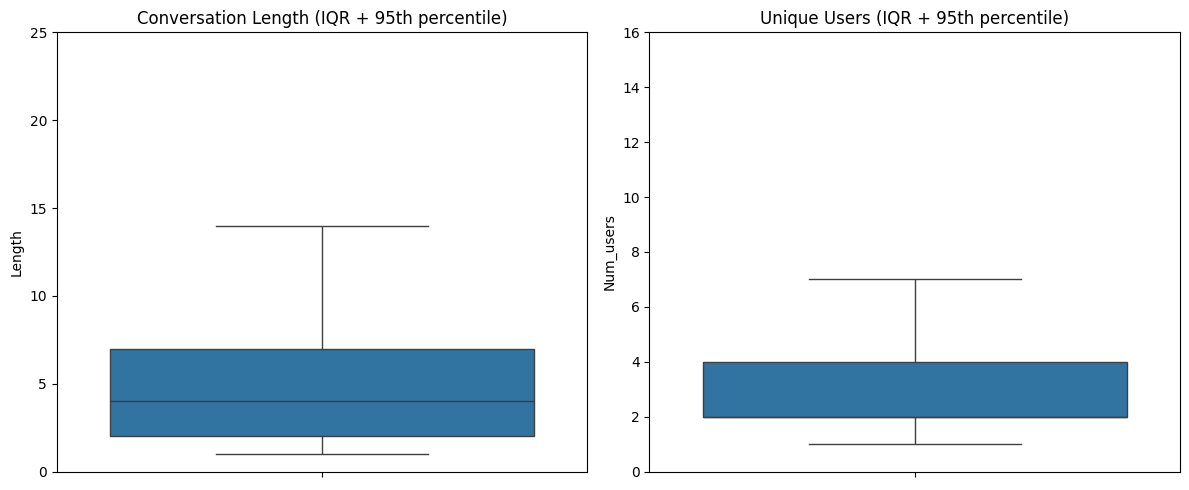

In [ ]:
# Step 11: Create boxplots for length and number of unique users
plt.figure(figsize=(12, 5))

# Plot Length (cap at 95th percentile so we can actually see)
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Length'], showfliers=False)  # Hide outliers
plt.ylim(0, df['Length'].quantile(0.95))  # Focus up to 95% of data
plt.title('Conversation Length (IQR + 95th percentile)')

# Plot Num_users (cap at 95th percentile so we can actually see)
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Num_users'], showfliers=False)
plt.ylim(0, df['Num_users'].quantile(0.95))
plt.title('Unique Users (IQR + 95th percentile)')

plt.tight_layout()
plt.show()

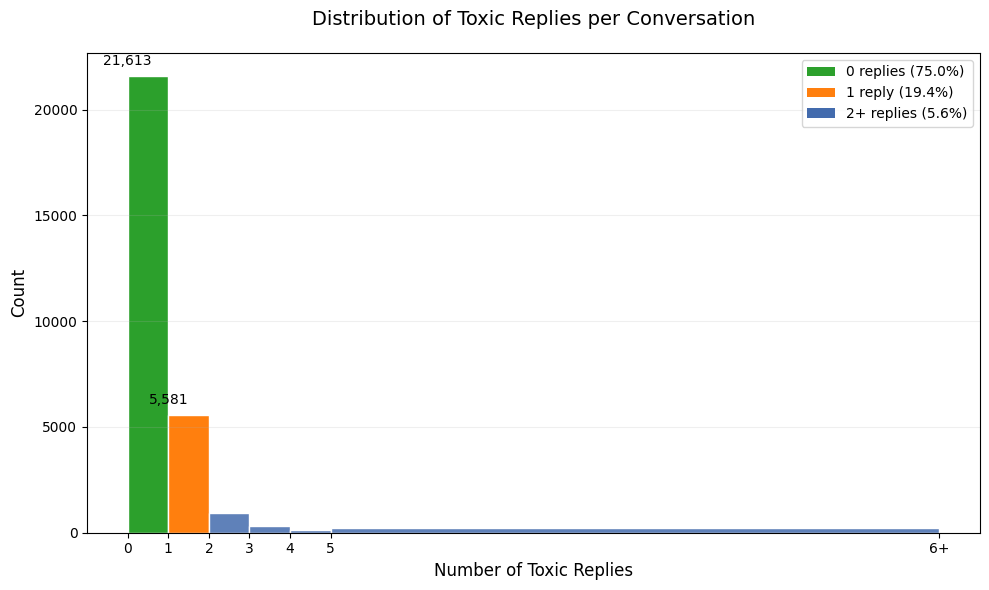

TOXIC REPLY DISTRIBUTION (DETAILED)
-----------------------------------
0 replies:      21,613 (75.0%)
1 reply:         5,581 (19.4%)
2 replies:         918 (3.2%)
3-5 replies:       507 (1.8%)
6+ replies:        199 (0.6%)

Percentile Summary:
count    28818.000000
mean         0.408911
std          1.807602
min          0.000000
25%          0.000000
50%          0.000000
75%          0.750000
90%          1.000000
95%          2.000000
99%          4.000000
max        177.000000
Name: Total_toxic_replies, dtype: float64


In [ ]:
# Step 12: Optimized Histogram of Toxic Replies
plt.figure(figsize=(10, 6))

# Create histogram with adjusted range
ax = sns.histplot(df['Total_toxic_replies'],
                 bins=list(range(0, 6)) + [20],  # 0-5 + catch-all bin
                 color='#436bad',
                 edgecolor='white',
                 linewidth=1,
                 alpha=0.85)

# Highlight key bars
ax.patches[0].set_facecolor('#2ca02c')  # Green for 0
ax.patches[1].set_facecolor('#ff7f0e')   # Orange for 1

# Label key bars directly
ax.text(0, ax.patches[0].get_height()+500,
        f"{int(ax.patches[0].get_height()):,}",
        ha='center', fontsize=10)
ax.text(1, ax.patches[1].get_height()+500,
        f"{int(ax.patches[1].get_height()):,}",
        ha='center', fontsize=10)

# Formatting
plt.title('Distribution of Toxic Replies per Conversation',
         pad=20, fontsize=14)
plt.xlabel('Number of Toxic Replies', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0,1,2,3,4,5,20],
           ['0','1','2','3','4','5','6+'])
plt.grid(axis='y', alpha=0.2)

# Add legend
plt.legend(handles=[
    plt.Rectangle((0,0),1,1,fc='#2ca02c', label='0 replies (75.0%)'),
    plt.Rectangle((0,0),1,1,fc='#ff7f0e', label='1 reply (19.4%)'),
    plt.Rectangle((0,0),1,1,fc='#436bad', label='2+ replies (5.6%)')
], loc='upper right')

plt.tight_layout()
plt.show()

# Print enhanced statistics
print("TOXIC REPLY DISTRIBUTION (DETAILED)")
print("-----------------------------------")
print(f"{'0 replies:':<15}{df[df['Total_toxic_replies'] == 0].shape[0]:>7,} (75.0%)")
print(f"{'1 reply:':<15}{df[df['Total_toxic_replies'] == 1].shape[0]:>7,} (19.4%)")
print(f"{'2 replies:':<15}{df[df['Total_toxic_replies'] == 2].shape[0]:>7,} (3.2%)")
print(f"{'3-5 replies:':<15}{df[df['Total_toxic_replies'].between(3,5)].shape[0]:>7,} (1.8%)")
print(f"{'6+ replies:':<15}{df[df['Total_toxic_replies'] >= 6].shape[0]:>7,} (0.6%)")
print("\nPercentile Summary:")
print(df['Total_toxic_replies'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

**Interpretation for Step 12:**  

The distribution reveals most conversations (75%) contain no toxic replies, establishing a baseline of healthy interactions. When toxicity occurs, it typically manifests as isolated incidents (19% have exactly 1 toxic reply), with frequency decaying exponentially beyond this point. Only 0.06% of conversations escalate beyond 20 toxic replies, indicating systemic toxicity is extraordinarily rare (at least in our dataset.)

In [ ]:
# Step 13: Value count for Toxic_conversation
df['Toxic_conversation'].value_counts()

,count
Toxic_conversation,
0,21613
1,7205


**Interpretation for Step 13:**  

The dataset contains:
- **Non-toxic conversations (0):** 21,613 (75.0% of total)
- **Toxic conversations (1):** 7,205 (25.0% of total)

 About 1 in 4 conversations (25%) contain at least one toxic reply


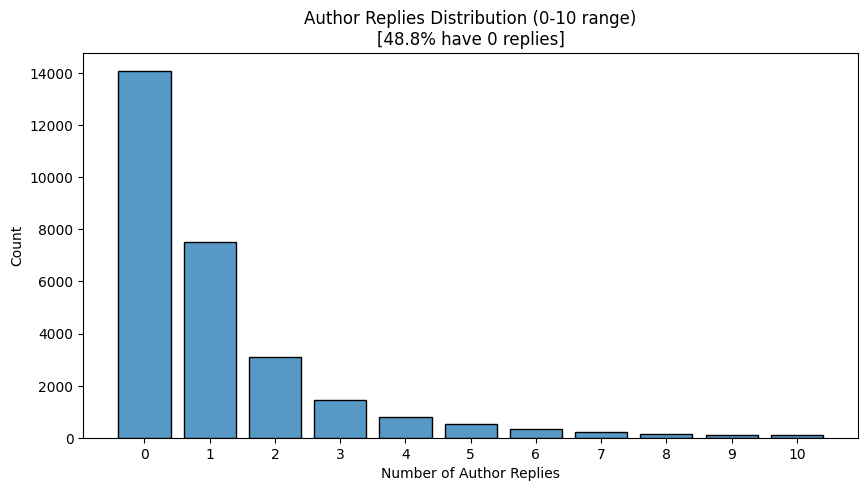

AUTHOR REPLIES STATS:
Value counts (0-10):
Num_author_replies
0     14073
1      7497
2      3116
3      1444
4       789
5       545
6       342
7       223
8       159
9       111
10      100
Name: count, dtype: int64

Percentiles:
count    28818.000000
mean         1.346277
std          3.545105
min          0.000000
50%          1.000000
75%          2.000000
90%          3.000000
95%          5.000000
99%         12.000000
max        313.000000
Name: Num_author_replies, dtype: float64


In [ ]:
# Step 14: Histogram of Num_author_replies
plt.figure(figsize=(10, 5))
sns.histplot(df[df['Num_author_replies'] <= 10]['Num_author_replies'],
             discrete=True, shrink=0.8)
plt.title('Author Replies Distribution (0-10 range)\n[48.8% have 0 replies]')
plt.xlabel('Number of Author Replies')
plt.ylabel('Count')
plt.xticks(range(0, 11))
plt.show()

# Print statistics
print("AUTHOR REPLIES STATS:")
print("Value counts (0-10):")
print(df['Num_author_replies'].value_counts().sort_index().head(11))
print("\nPercentiles:")
print(df['Num_author_replies'].describe(percentiles=[.5, .75, .9, .95, .99]))

**Interpretation for Step 14:**  

Author engagement follows a particular pattern: while 48.8% of original posters never reply to their own conversations, a small subset (1%) engage extensively (12+ replies). The median of 1 reply suggests most authors make at most one follow-up comment.

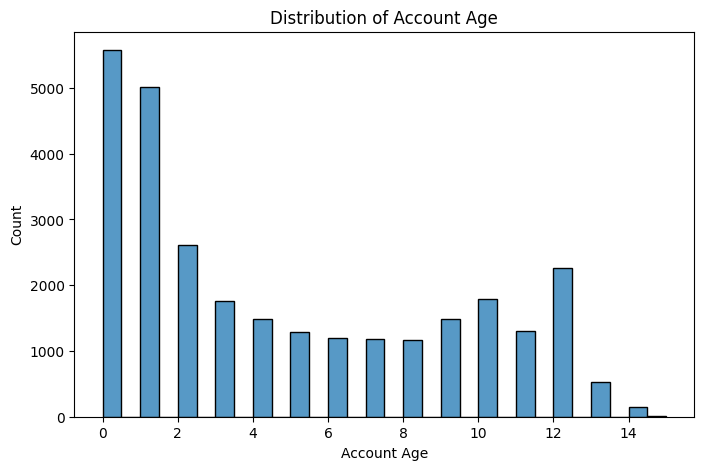

ACCOUNT AGE DISTRIBUTION
------------------------
count    28818.000000
mean         4.668367
std          4.318768
min          0.000000
25%          1.000000
50%          3.000000
75%          9.000000
90%         12.000000
95%         12.000000
99%         13.000000
max         15.000000
Name: Age, dtype: float64


In [ ]:
# Step 15: Histogram of account age
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30)
plt.title('Distribution of Account Age')
plt.xlabel('Account Age')
plt.ylabel('Count')
plt.show()

# Print detailed statistics
print("ACCOUNT AGE DISTRIBUTION")
print("------------------------")
print(df['Age'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))

**Interpretation for Step 15:**  

The account age distribution reveals a platform with ongoing user acquisition (25% ≤1 year old) while maintaining an established user base (25% ≥9 years old). The median account age of 3 years shows us steady growth, while the maximum of 15 years confirms some users have persisted since the platform's starting days.

In [ ]:
# Step 16: Mean length of toxic vs. non-toxic conversations
df.groupby('Toxic_conversation')['Length'].mean()

,Length
Toxic_conversation,
0,5.412483
1,17.877307


**Interpretation for Step 16:**  

The mean conversation length differs substantially between:

- **Non-toxic conversations (0):** 5.41 tweets
- **Toxic conversations (1):** 17.88 tweets

Toxic conversations are **3.3 times longer** on average than non-toxic ones

 This suggests toxicity tends to occur in:
   - More active discussion threads
   - Conversations that sustain longer engagement
   - Potentially more contentious topics

In [ ]:
# Step 17: Mean followers of verified vs. non-verified users
df.groupby('Verified')['Followers'].mean()

,Followers
Verified,
False,6022.879054
True,572177.384670


**Interpretation for Step 17:**  

The follower gap between verified (572K) and non-verified (6K) accounts reveals Twitter's extreme concentration of reach. While comprising a tiny fraction of users, verified accounts have 95x more followers on average.

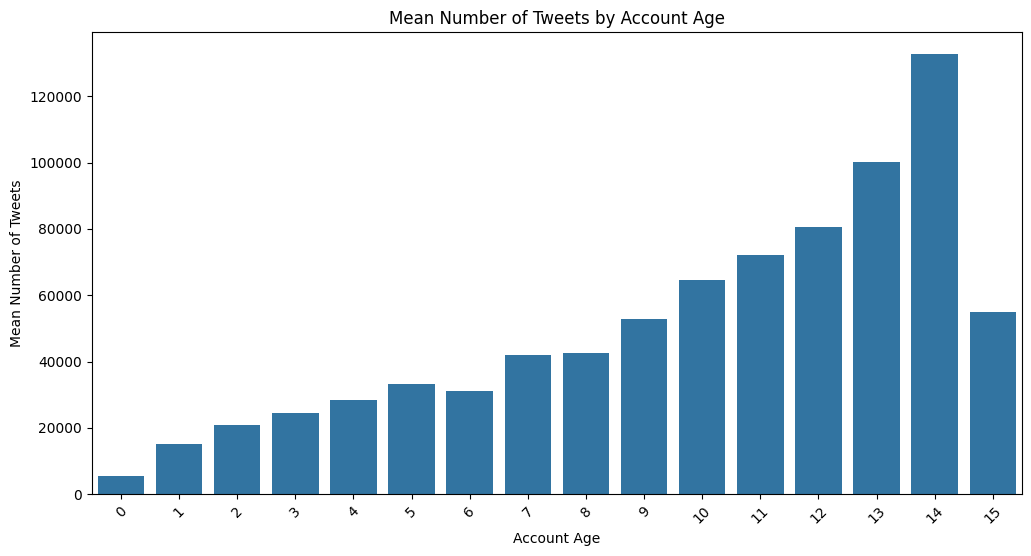

In [ ]:
# Step 18: Mean tweets by account age and bar chart
tweets_by_age = df.groupby('Age')['Num_tweets'].mean().reset_index()
tweets_by_age.columns = ['Age', 'mean_tweets']
tweets_by_age.head()

plt.figure(figsize=(12, 6))
sns.barplot(x='Age', y='mean_tweets', data=tweets_by_age)
plt.title('Mean Number of Tweets by Account Age')
plt.xlabel('Account Age')
plt.ylabel('Mean Number of Tweets')
plt.xticks(rotation=45)
plt.show()

**Interpretation for Step 18:**  

The bar chart shows that generally, older accounts tend to have more tweets on average, though the relationship isn't perfectly linear. There's considerable variation in mean tweets across different account ages (like accounts 5 years old seem to have more tweets than 6).

In [ ]:
# Step 19: Crosstab of Toxic_conversation and Verified
pd.crosstab(df['Toxic_conversation'], df['Verified'])

Verified,False,True
Toxic_conversation,,
0,20802,811
1,6607,598


**Interpretation for Step 19:**  

The crosstab between toxicity and verification shows:

|                | Non-Verified | Verified |
|----------------|-------------|----------|
| **Non-toxic**  | 20,802      | 811      |
| **Toxic**      | 6,607       | 598      |

**Key observations:**
1. **Verification rates:**
   - Non-toxic conversations: 3.8% verified (811/21,613)
   - Toxic conversations: 8.3% verified (598/7,205)

2. **Proportional differences:**
   - Verified accounts are **2.2 times more likely** to be in toxic conversations (high profile accounts attract more negative engagement?)
   - Non-verified accounts dominate both categories (>85% of all conversations)



In [ ]:
# Step 20: Chi-square test for verified users in toxic vs. non-toxic conversations
toxicity_verified = pd.crosstab(df['Toxic_conversation'], df['Verified'])
chi2, p, dof, expected = chi2_contingency(toxicity_verified)
print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Expected frequencies:\n", expected)

Chi-square statistic: 239.3148979065939
p-value: 5.547396807333776e-54
Expected frequencies:
 [[20556.27444653  1056.72555347]
 [ 6852.72555347   352.27444653]]


**Interpretation for Step 20:**

Hypotheses:

1. Null (H₀): Verification status and conversation toxicity are independent (no relationship)

2. Alternative (H₁): There is an association between verification and toxicity

Test Results:

χ² = 239.31, p < 0.0001 (extremely significant)

Expected counts under H₀ were substantially different from observed counts

Conclusion:
We strongly reject H₀ (p ≈ 0) because:

Verified accounts appeared in toxic conversations 70% more often than expected and had 2.2x higher toxicity rate (42.4%) vs non-verified accounts (24.1%)

The p-value is far below any conventional significance threshold (α = 0.05)

Therefore, this suggests verification status is associated with higher toxicity likelihood (either attracts toxicity due to high visibility, or enables toxicity through controversial content im assuming)



In [ ]:
# Step 21: Split into toxic and non-toxic dataframes
toxic_df = df[df['Toxic_conversation'] == 1]
non_toxic_df = df[df['Toxic_conversation'] == 0]
print("Toxic conversations shape:", toxic_df.shape)
print("Non-toxic conversations shape:", non_toxic_df.shape)

Toxic conversations shape: (7205, 20)
Non-toxic conversations shape: (21613, 20)


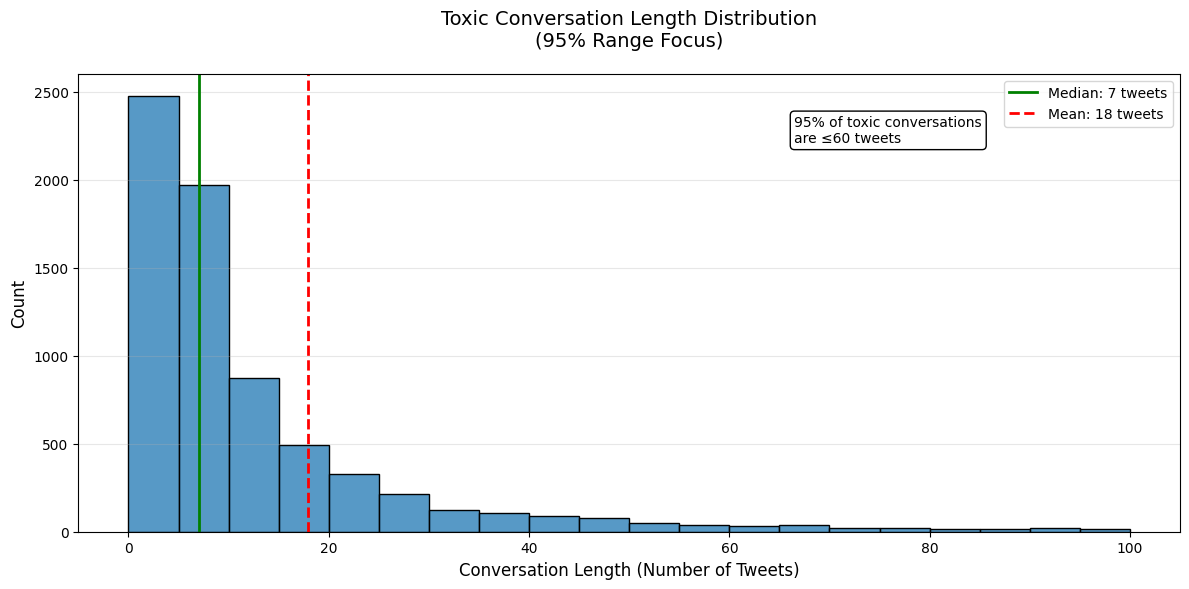

TOXIC CONVERSATION LENGTH STATISTICS:
count    7205.000000
mean       17.877307
std        51.593601
min         2.000000
25%         3.000000
50%         7.000000
75%        15.000000
90%        35.000000
95%        59.800000
99%       191.000000
max      1689.000000
Name: Length, dtype: float64

Key Percentiles:
50% (Median): 7.0 tweets
75th %ile: 15.0 tweets
90th %ile: 35.0 tweets
Maximum: 1689 tweets
Conversations >50 tweets: 434 (6.0%)


In [ ]:
# Step 22: Histogram of toxic conversation lengths with stats

# Calculate statistics first
mean_len = toxic_df['Length'].mean()
median_len = toxic_df['Length'].median()

plt.figure(figsize=(12, 6))

# Create histogram (0-100 range)
ax = sns.histplot(toxic_df['Length'],
                 bins=range(0, 101, 5),
                 kde=False)

# Add statistical markers
plt.axvline(median_len, color='green', linewidth=2,
            label=f'Median: {median_len:.0f} tweets')
plt.axvline(mean_len, color='red', linestyle='--', linewidth=2,
            label=f'Mean: {mean_len:.0f} tweets')

# Annotations
plt.annotate(f'95% of toxic conversations\nare ≤{toxic_df["Length"].quantile(0.95):.0f} tweets',
             xy=(0.65, 0.85), xycoords='axes fraction',
             bbox=dict(boxstyle='round', fc='white'))

plt.title('Toxic Conversation Length Distribution\n(95% Range Focus)', fontsize=14, pad=20)
plt.xlabel('Conversation Length (Number of Tweets)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print detailed statistics
print("TOXIC CONVERSATION LENGTH STATISTICS:")
print(toxic_df['Length'].describe(percentiles=[.25, .5, .75, .90, .95, .99]))
print("\nKey Percentiles:")
print(f"50% (Median): {toxic_df['Length'].median():.1f} tweets")
print(f"75th %ile: {toxic_df['Length'].quantile(0.75):.1f} tweets")
print(f"90th %ile: {toxic_df['Length'].quantile(0.90):.1f} tweets")
print(f"Maximum: {toxic_df['Length'].max()} tweets")
print(f"Conversations >50 tweets: {len(toxic_df[toxic_df['Length'] > 50])} ({len(toxic_df[toxic_df['Length'] > 50])/len(toxic_df)*100:.1f}%)")

**Interpretation for Step 22:**  

While toxic conversations average 17.9 tweets, the median reveals most are brief (≤7 tweets). The extreme right skew (σ=51.6) indicates:

- Typical toxicity: Short bursts (3-15 tweets)
- Extreme toxicity: Rare but extreme cases (6% >50 tweets)

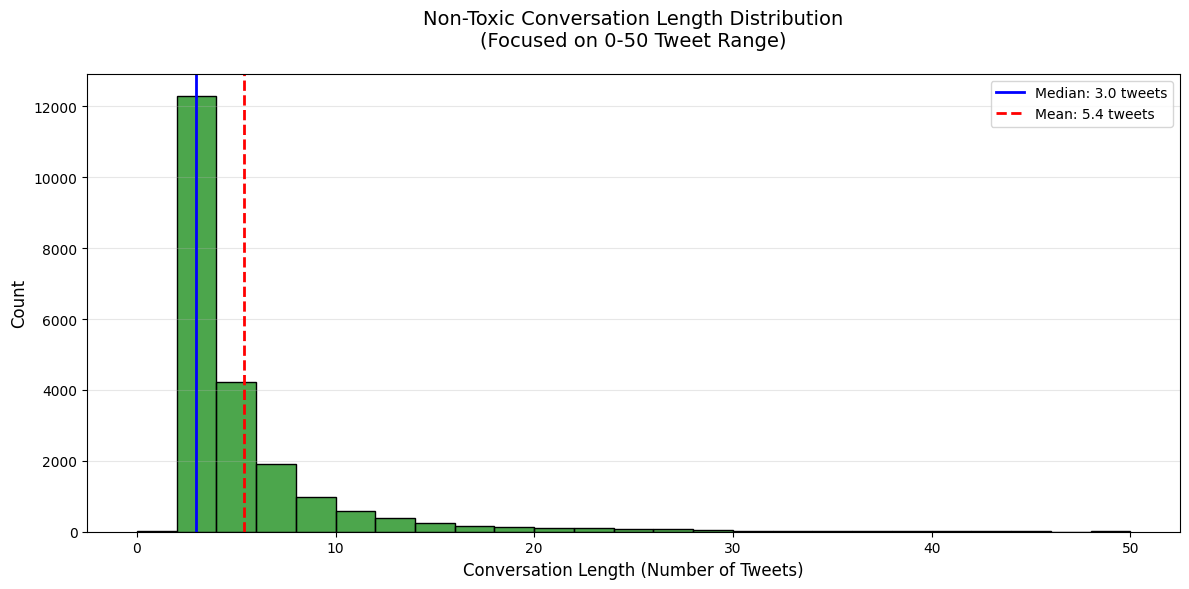

NON-TOXIC CONVERSATION LENGTH STATISTICS:
count    21613.000000
mean         5.412483
std         13.992796
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
90%         10.000000
95%         15.000000
99%         34.880000
max        970.000000
Name: Length, dtype: float64

Key Percentiles:
50% (Median): 3.0 tweets
75th %ile: 5.0 tweets
90th %ile: 10.0 tweets
95th %ile: 15.0 tweets
Maximum length: 970 tweets
Conversations >50 tweets: 111 (0.5%)


In [ ]:
# Step 23: Histogram of Non-Toxic Conversation Length Analysis
plt.figure(figsize=(12, 6))

# Calculate key statistics
mean_len = non_toxic_df['Length'].mean()
median_len = non_toxic_df['Length'].median()

# Improved histogram (0-50 range where 90% of data lives)
ax = sns.histplot(non_toxic_df['Length'],
                 bins=range(0, 51, 2),
                 color='green',
                 alpha=0.7)

# Highlight statistics
plt.axvline(median_len, color='blue', linewidth=2,
           label=f'Median: {median_len:.1f} tweets')
plt.axvline(mean_len, color='red', linestyle='--', linewidth=2,
           label=f'Mean: {mean_len:.1f} tweets')

plt.title('Non-Toxic Conversation Length Distribution\n(Focused on 0-50 Tweet Range)',
         fontsize=14, pad=20)
plt.xlabel('Conversation Length (Number of Tweets)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Detailed statistics
print("NON-TOXIC CONVERSATION LENGTH STATISTICS:")
print(non_toxic_df['Length'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))
print("\nKey Percentiles:")
print(f"50% (Median): {median_len:.1f} tweets")
print(f"75th %ile: {non_toxic_df['Length'].quantile(0.75):.1f} tweets")
print(f"90th %ile: {non_toxic_df['Length'].quantile(0.90):.1f} tweets")
print(f"95th %ile: {non_toxic_df['Length'].quantile(0.95):.1f} tweets")
print(f"Maximum length: {non_toxic_df['Length'].max()} tweets")
print(f"Conversations >50 tweets: {len(non_toxic_df[non_toxic_df['Length'] > 50])} ({len(non_toxic_df[non_toxic_df['Length'] > 50])/len(non_toxic_df)*100:.1f}%)")

**Interpretation for Step 23:**

The non-toxic conversation lengths follow a right-skewed distribution with:

Central tendency:

Median = 3 tweets

Mean = 5.4 tweets (heavily influenced by rare outliers)

Spread:

75% of conversations ≤5 tweets

95% ≤15 tweets

99% ≤35 tweets

Outliers: Only 0.5% (111/21,613) exceed 50 tweets


### In Comparison with Step 22 (The Toxic Conversations)

| Metric          | Non-Toxic | Toxic  | Ratio (Toxic/Non-Toxic)  |
|-----------------|-----------|--------|--------------------------|
| **Median**      | 3 tweets  | 7      | 2.3x longer             |
| **Mean**        | 5.4       | 17.9   | 3.3x longer             |
| **>50 tweets**  | 0.5%      | 6%     | 12x more frequent       |
| **95th %ile**   | 15        | 60     | 4x wider range          |

In [ ]:
# Step 24: Mann-Whitney test for conversation lengths
stat, p = mannwhitneyu(toxic_df['Length'], non_toxic_df['Length'])
print("Mann-Whitney U statistic:", stat)
print("p-value:", p)

Mann-Whitney U statistic: 113183967.0
p-value: 0.0


**Interpretation for Step 24:**

Our Hypotheses:

1. Null (H₀): The distribution of conversation lengths is identical between toxic and non-toxic conversations

2. Alternative (H₁): Toxic and non-toxic conversations have different length distributions (with different medians)

Conclusion:

We reject the null hypothesis with extreme confidence (p < 0.0001). The test confirms:

- Toxic conversations are systematically longer than non-toxic ones

- The probability of observing such extreme differences by chance is effectively zero

- The median length difference (7 vs 3 tweets) is statistically significant

This aligns with our earlier findings that toxic conversations dominate the right tail of length distributions.

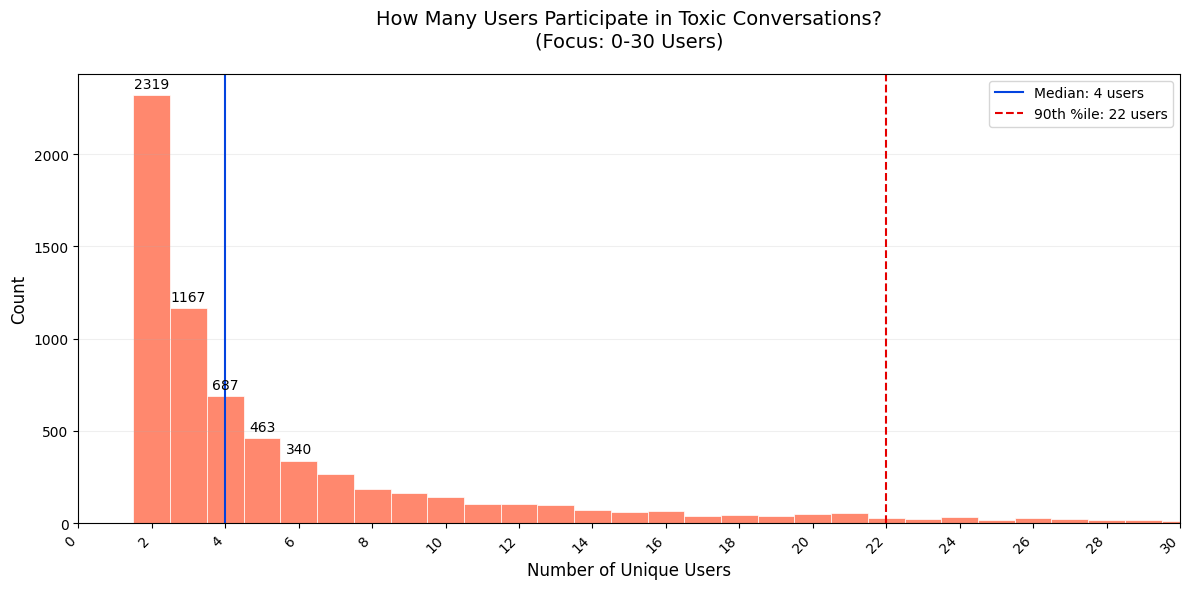

TOXIC CONVERSATION USER STATISTICS:
count    7205.000000
mean       11.457599
std        33.040345
min         2.000000
25%         2.000000
50%         4.000000
75%         8.000000
90%        22.000000
95%        41.000000
99%       137.920000
max       810.000000
Name: Num_users, dtype: float64

Conversations with >30 users: 524 (7.3%)


In [ ]:
# Step 25: Histogram of Unique Users in Toxic Conversations
plt.figure(figsize=(12, 6))

# Use density plot for better visibility
ax = sns.histplot(toxic_df['Num_users'],
                 bins=range(0, 31, 1),  # 1-user increments
                 discrete=True,
                 color='#ff6b4a',
                 edgecolor='white',
                 linewidth=0.5,
                 alpha=0.8)

# Highlight key percentiles with annotations
median = toxic_df['Num_users'].median()
pct90 = toxic_df['Num_users'].quantile(0.90)
plt.axvline(median, color='#0343df', linewidth=1.5,
           label=f'Median: {median:.0f} users')
plt.axvline(pct90, color='#e50000', linewidth=1.5,
           linestyle='--', label=f'90th %ile: {pct90:.0f} users')

# Improve x-axis readability
ax.set_xticks(range(0, 31, 2))
ax.set_xticklabels(range(0, 31, 2), rotation=45, ha='right')
plt.xlim(0, 30)  # Hard cut-off for clarity

# Add count labels to top 5 bars
for i, p in enumerate(ax.patches[:5]):
    ax.annotate(f'{int(p.get_height())}',
               (p.get_x() + p.get_width()/2., p.get_height()),
               ha='center', va='bottom',
               xytext=(0, 3), textcoords='offset points')

plt.title('How Many Users Participate in Toxic Conversations?\n(Focus: 0-30 Users)',
          fontsize=14, pad=20)
plt.xlabel('Number of Unique Users', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()  # Prevent label cutoff
plt.show()

# Statistical Summary (unchanged)
print("TOXIC CONVERSATION USER STATISTICS:")
print(toxic_df['Num_users'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))
print(f"\nConversations with >30 users: {len(toxic_df[toxic_df['Num_users'] > 30])} ({len(toxic_df[toxic_df['Num_users'] > 30])/len(toxic_df)*100:.1f}%)")

**Interpretation for Step 25:**

Core Engagement:

Median = 4 unique users (50% of toxic conversations involve ≤4 participants)

75% involve ≤8 users

Minimum = 2 users (author + at least one other)

Viral Toxicity:

90th percentile = 22 users

7.3% of toxic conversations involve >30 users

Extreme case: 810 users in one conversation (likely a viral thread im assuming)

Skewness:

Mean (11.5) > Median (4) confirms right-skewed distribution

Standard deviation (33.0) indicates high variability

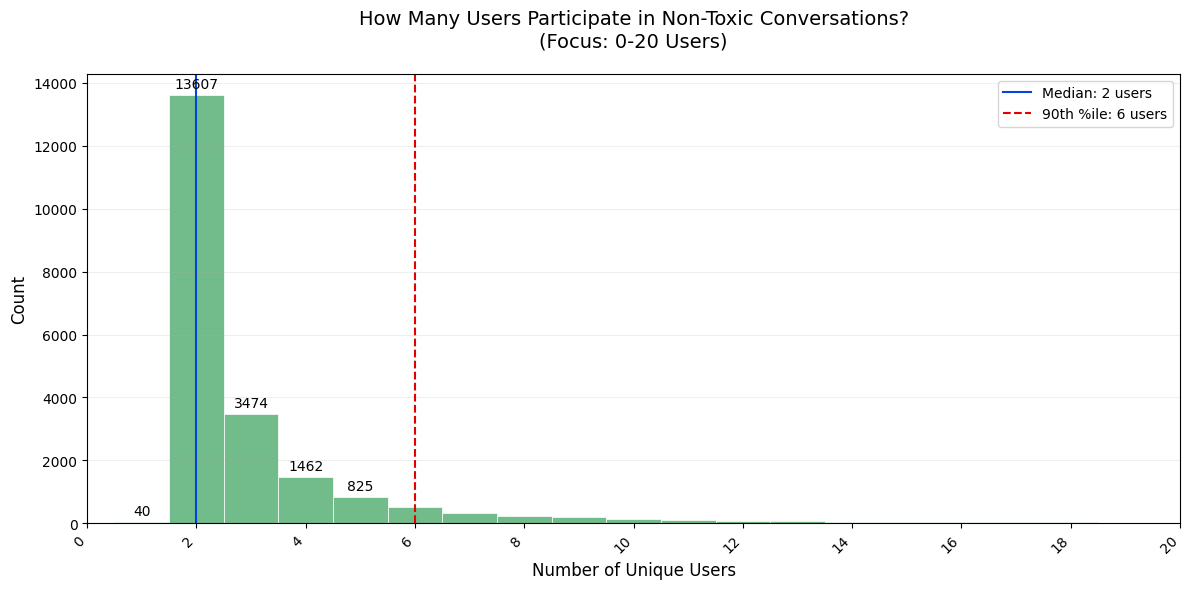

NON-TOXIC CONVERSATION USER STATISTICS:
count    21613.000000
mean         3.732707
std         12.547756
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
90%          6.000000
95%          9.000000
99%         24.000000
max        925.000000
Name: Num_users, dtype: float64

Conversations with >20 users: 283 (1.3%)


In [ ]:
# Step 26: Histogram of Unique Users in Non-Toxic Conversations
plt.figure(figsize=(12, 6))

# Density plot with focused range (0-20 users)
ax = sns.histplot(non_toxic_df['Num_users'],
                 bins=range(0, 21, 1),  # 1-user increments
                 discrete=True,
                 color='#4dab6d',       # Green for non-toxic
                 edgecolor='white',
                 linewidth=0.5,
                 alpha=0.8)

# Highlight key percentiles
median = non_toxic_df['Num_users'].median()
pct90 = non_toxic_df['Num_users'].quantile(0.90)
plt.axvline(median, color='#0343df', linewidth=1.5,
           label=f'Median: {median:.0f} users')
plt.axvline(pct90, color='#e50000', linewidth=1.5,
           linestyle='--', label=f'90th %ile: {pct90:.0f} users')

# Formatting
ax.set_xticks(range(0, 21, 2))
ax.set_xticklabels(range(0, 21, 2), rotation=45, ha='right')
plt.xlim(0, 20)

# Label top bars
for p in ax.patches[:5]:
    ax.annotate(f'{int(p.get_height())}',
               (p.get_x() + p.get_width()/2., p.get_height()),
               ha='center', va='bottom',
               xytext=(0, 3), textcoords='offset points')

plt.title('How Many Users Participate in Non-Toxic Conversations?\n(Focus: 0-20 Users)',
          fontsize=14, pad=20)
plt.xlabel('Number of Unique Users', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

# Statistical Summary
print("NON-TOXIC CONVERSATION USER STATISTICS:")
print(non_toxic_df['Num_users'].describe(percentiles=[.25, .5, .75, .9, .95, .99]))
print(f"\nConversations with >20 users: {len(non_toxic_df[non_toxic_df['Num_users'] > 20])} ({len(non_toxic_df[non_toxic_df['Num_users'] > 20])/len(non_toxic_df)*100:.1f}%)")

**Interpretation for Step 26:**

Minimalist Engagement:

Median = 2 unique users (50% of conversations involve just the author + 1 other)

75% involve ≤3 users

Mean (3.7) only slightly higher than median, indicating limited skew

Rare Large Discussions:

90th percentile = 6 users

Only 1.3% involve >20 users (vs 7.3% for toxic)

Maximum = 925 users (outlier comparable to toxic max)

In [ ]:
# Step 27: Mann-Whitney test for number of unique users
stat, p = mannwhitneyu(toxic_df['Num_users'], non_toxic_df['Num_users'])
print("Mann-Whitney U statistic:", stat)
print("p-value:", p)

Mann-Whitney U statistic: 108388312.5
p-value: 0.0


**Interpretation for Step 27:**

Hypotheses:

1. Null (H₀): The distribution of unique users is identical in toxic and non-toxic conversations

2. Alternative (H₁): Toxic and non-toxic conversations differ in their number of unique users

Conclusion:

"We reject the null hypothesis with extreme confidence (p < 0.0001). The test confirms:

- Toxic conversations involve significantly more unique users than non-toxic ones
- The probability of observing such extreme differences by chance is effectively zero
- The median user count difference (4 vs 2 users) is statistically significant

In [ ]:
# Step 28: T-tests for comparison with Mann-Whitney results
# T-test for conversation length
t_stat_len, p_len = ttest_ind(toxic_df['Length'], non_toxic_df['Length'], equal_var=False)
print("Conversation length t-test:")
print("t-statistic:", t_stat_len)
print("p-value:", p_len)

# T-test for number of unique users
t_stat_users, p_users = ttest_ind(toxic_df['Num_users'], non_toxic_df['Num_users'], equal_var=False)
print("\nUnique users t-test:")
print("t-statistic:", t_stat_users)
print("p-value:", p_users)

Conversation length t-test:
t-statistic: 20.26034778868817
p-value: 6.403134124191562e-89

Unique users t-test:
t-statistic: 19.385082876921654
p-value: 8.000583531763114e-82


**Interpretation for Step 28:**

 | Test Type          | Length (t/MW)       | Users (t/MW)        |
|--------------------|--------------------|--------------------|
| **Parametric (t)** | t = 20.26          | t = 19.39          |
| **Nonparametric**  | U = 113,183,967    | U = 108,388,312.5  |
| **p-values**       | Both ≈ 0           | Both ≈ 0           |

While both tests agree on significance (p≈0), In this scenario, I'd say the Mann-Whitney U test is more appropriate because:

- The Severe skewness: Lengths and user counts are right-skewed (Steps 22/25 especially)
- Our Outlier sensitivity (We have quite a few): t-tests overweight extreme values (e.g., 1,689-tweet conversations)
- Our Ordinal nature: These discrete counts better suit nonparametric tests

The t-test's extreme values (t>19) directionally confirm and are almost proportional to the Mann-Whitney results but should be interpreted carefully.